In [136]:
import pandas as pd

In [137]:
data = pd.read_csv('merged_similarity_analysis.csv')
data.head(20)

,file_name,similar_file,similarity_100,similarity_200,similarity_350,similarity_500,similarity_750,similarity_1000
0,title_000fafe617351d803c43c1cf03a3830c,title_000fafe617351d803c43c1cf03a3830c,0.406557,0.474840,0.505193,0.545425,0.565756,0.581215
1,title_000fafe617351d803c43c1cf03a3830c,title_007ae424be3f6915cc43a13cbdde5242,0.352807,0.382060,0.407102,0.420848,0.428988,0.434961
2,title_000fafe617351d803c43c1cf03a3830c,title_0101833702d72ed1d6b4ffa2264d21e8,0.305840,0.336645,0.000000,0.000000,0.000000,0.000000
3,title_000fafe617351d803c43c1cf03a3830c,title_016901293c3d740ab6147e0682bfa610,0.000000,0.338824,0.374679,0.396759,0.410166,0.418538
4,title_000fafe617351d803c43c1cf03a3830c,title_01fc8de735a538d4b0cf97ce2df1c750,0.358850,0.408957,0.443339,0.466676,0.481811,0.489813
5,title_000fafe617351d803c43c1cf03a3830c,title_02cff35838d45dad4af354353d5a0674,0.387470,0.433129,0.461597,0.480350,0.491115,0.496799
6,title_000fafe617351d803c43c1cf03a3830c,title_03eb51dcb5d72e2da5346761d9c34bcc,0.370756,0.406886,0.436189,0.454084,0.467188,0.471554
7,title_000fafe617351d803c43c1cf03a3830c,title_03f7384159d366707c6a9745506cd575,0.309585,0.346432,0.377455,0.401866,0.416047,0.423991
8,title_000fafe617351d803c43c1cf03a3830c,title_03f8c68762d6059056f854f69b1b650f,0.317310,0.365296,0.394094,0.413561,0.428304,0.436063
9,title_000fafe617351d803c43c1cf03a3830c,title_04122ed4296305cbf7aadf1e242c759e,0.306313,0.349766,0.381170,0.397255,0.408708,0.414426


C:\Users\dangs\AppData\Local\Temp\ipykernel_10664\214272021.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


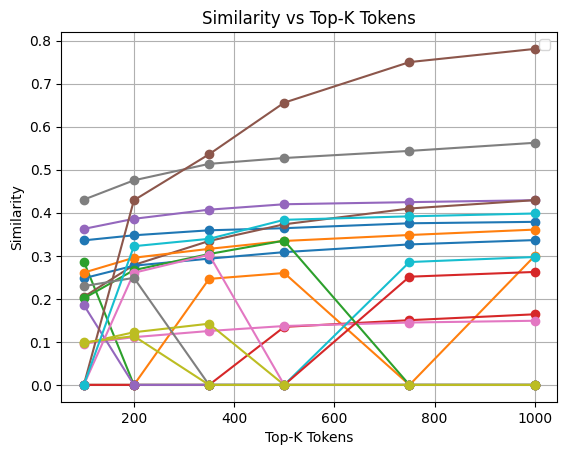

In [138]:
import matplotlib.pyplot as plt

# Select a few rows to visualize
sample_rows = data.sample(n=20)  # Randomly select n rows for plotting

x = [int(col.split("_")[-1]) for col in data.columns[2:]]

for idx, row in sample_rows.iterrows():
    y = row[2:].values.astype(float)
    plt.plot(x, y, marker='o')

plt.xlabel("Top-K Tokens")
plt.ylabel("Similarity")
plt.title("Similarity vs Top-K Tokens")
plt.legend()
plt.grid(True)

plt.show()

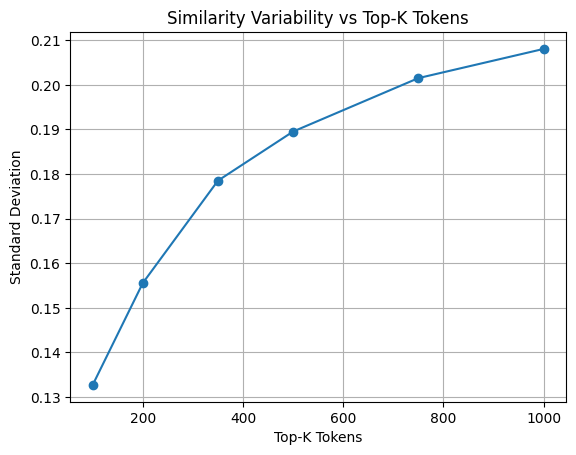

In [139]:
std_dev = data.iloc[:, 2:].std(axis=0)

plt.plot(x, std_dev, marker='o')

plt.xlabel("Top-K Tokens")
plt.ylabel("Standard Deviation")
plt.title("Similarity Variability vs Top-K Tokens")
plt.grid(True)

plt.show()

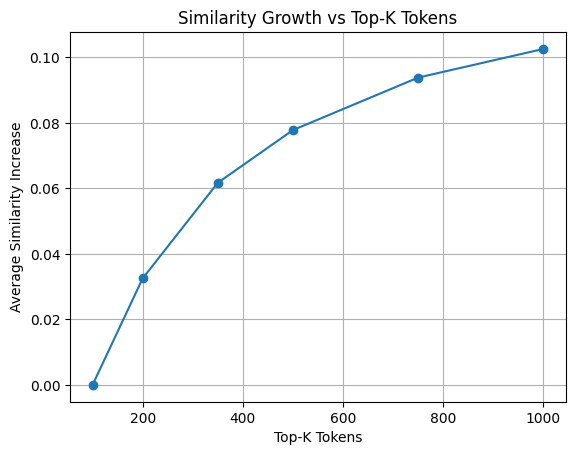

In [140]:
baseline = data["similarity_100"]

growth = data.iloc[:, 2:].subtract(baseline, axis=0)
y = growth.mean(axis=0)

plt.plot(x, y, marker='o')

plt.xlabel("Top-K Tokens")
plt.ylabel("Average Similarity Increase")
plt.title("Similarity Growth vs Top-K Tokens")
plt.grid(True)

plt.show()

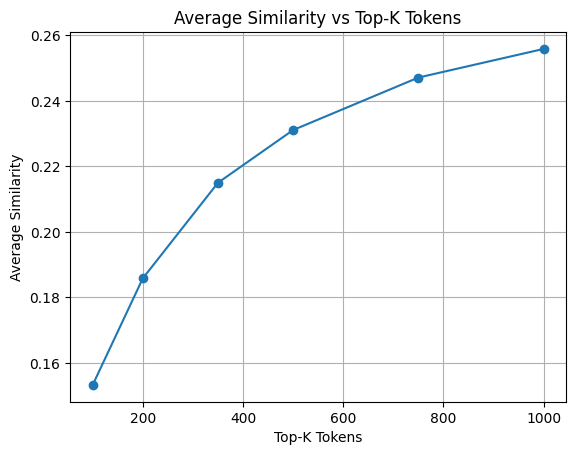

In [141]:
# Compute mean similarity at each TOP_K
y = data.iloc[:, 2:].mean(axis=0)

plt.plot(x, y, marker='o')

plt.xlabel("Top-K Tokens")
plt.ylabel("Average Similarity")
plt.title("Average Similarity vs Top-K Tokens")
plt.grid(True)

plt.show()

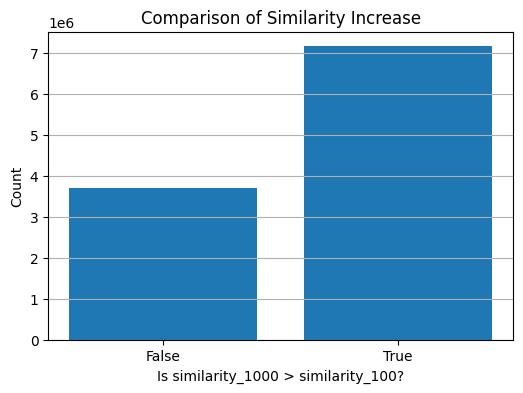

Percentage True: 0.6599610000023023


In [142]:
mask = data['similarity_1000'] > data['similarity_100']

counts = mask.value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['False', 'True'], counts.reindex([False, True], fill_value=0))

plt.xlabel('Is similarity_1000 > similarity_100?')
plt.ylabel('Count')
plt.title('Comparison of Similarity Increase')
plt.grid(axis='y')

plt.show()

print("Percentage True:", mask.mean())

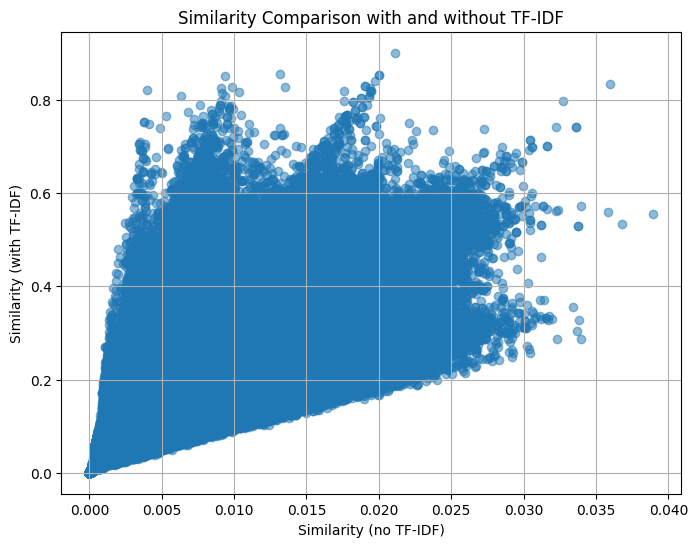

In [143]:
buff_data = pd.read_csv('fun_dataset.csv').iloc[:, -2:] # take last 2 columns
plt.figure(figsize=(8, 6))
plt.scatter(buff_data.iloc[:, 0], buff_data.iloc[:, 1], alpha=0.5)
plt.xlabel('Similarity (no TF-IDF)')
plt.ylabel('Similarity (with TF-IDF)')
plt.title('Similarity Comparison with and without TF-IDF')
plt.grid(True)
plt.show()

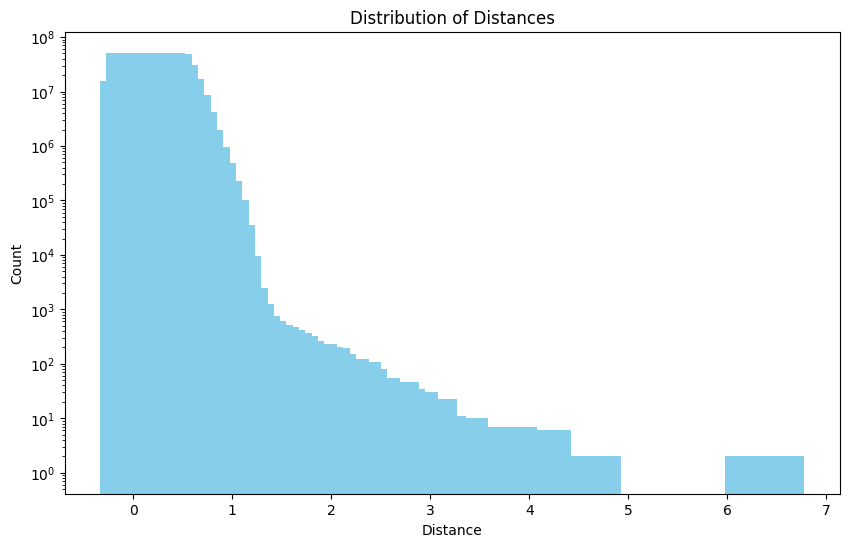

In [144]:
bar_dist = pd.read_csv('bin_info.csv')
plt.figure(figsize=(10, 6))
plt.bar(bar_dist['bin_end'], bar_dist['count'], color='skyblue')
plt.xlabel('Distance'); plt.ylabel('Count')
plt.yscale('log')
plt.title('Distribution of Distances')
plt.show()

In [145]:
import pandas as pd
import numpy as np

# Load your existing histogram table
bar_dist = pd.read_csv('bin_info.csv')  # columns: bin_index, count, bin_start, bin_end
bar_dist.tail(20)

,bin_index,count,bin_start,bin_end
47,47,6,3.001427,3.023829
48,48,2,3.083398,3.083417
49,49,10,3.142020,3.183702
50,50,1,3.244008,3.244008
51,51,3,3.277228,3.284347
52,52,6,3.338294,3.375622
53,53,4,3.394413,3.428430
54,54,1,3.484474,3.484474
55,55,2,3.520965,3.520978
56,56,4,3.607514,3.616089


In [153]:
target_count = bar_dist['count'].sum() * 0.86 # Top 86% of the data
print(f"Total count: {bar_dist['count'].sum()}, Target count for top 86%: {int(target_count)}")
temp = bar_dist.sort_values(by='bin_end', ascending=False).reset_index(drop=True)
temp['cumulative_count'] = temp['count'].cumsum()
threshold_index = temp[temp['cumulative_count'] >= target_count].index[0]
threshold_distance = temp.loc[threshold_index, 'bin_end']
print(f"Distance threshold for top 86%: {threshold_distance}")
temp.tail(20)

Total count: 180916790, Target count for top 86%: 155588439
Distance threshold for top 86%: 0.12757627197474


,bin_index,count,bin_start,bin_end,cumulative_count
47,19,483,1.212406e+00,1.275554,3818
48,18,524,1.148332e+00,1.211901,4342
49,17,605,1.084560e+00,1.147769,4947
50,16,745,1.020631e+00,1.084125,5692
51,15,1242,9.568293e-01,1.020532,6934
52,14,2492,8.930352e-01,0.956800,9426
53,13,9705,8.292510e-01,0.892982,19131
54,12,35835,7.654579e-01,0.829239,54966
55,11,99962,7.016698e-01,0.765457,154928
56,10,228734,6.378815e-01,0.701669,383662


In [166]:
results = []; sum_count = 0;  start = bar_dist['bin_start'].min(); end = 0
total = bar_dist['count'].sum()
target_count = 155588439/100
for bin_index in bar_dist['bin_index'].to_list():
    sum_count += bar_dist.loc[bar_dist['bin_index'] == bin_index, 'count'].values[0]
    if sum_count >= target_count:
        end = bar_dist.loc[bar_dist['bin_index'] == bin_index, 'bin_end'].values[0]
        results.append({
            "bin_start": start,
            "bin_end": end,
            "count": sum_count,
            "percentage": sum_count / total * 100
        })
        start = end
        sum_count = 0

if sum_count > 0:
    results.append({
        "bin_start": start,
        "bin_end": bar_dist['bin_end'].max(),
        "count": sum_count,
        "percentage": sum_count / total * 100
    })

results_df = pd.DataFrame(results)
# results_df = results_df.sort_values(by='bin_end', ascending=False).reset_index(drop=True)
results_df['cummulative_percentage'] = results_df['percentage'].cumsum()
# Rounding up to 4 decimal places
results_df['bin_start'] = results_df['bin_start'].round(4)
results_df['bin_end'] = results_df['bin_end'].round(4)

results_df.head(20)

,bin_start,bin_end,count,percentage,cummulative_percentage
0,0.0000,0.0638,15722477,8.690447,8.690447
1,0.0638,0.1276,51579028,28.509807,37.200254
2,0.1276,0.1914,49315569,27.258702,64.458956
3,0.1914,0.2552,31040972,17.157596,81.616552
4,0.2552,0.3189,16821437,9.297886,90.914438
5,0.3189,0.3827,8497280,4.696789,95.611227
6,0.3827,0.4465,4121547,2.278145,97.889372
7,0.4465,0.5103,1981250,1.095117,98.984489
8,0.5103,0.7017,1682302,0.929876,99.914365
9,0.7017,6.3788,154928,0.085635,100.000000


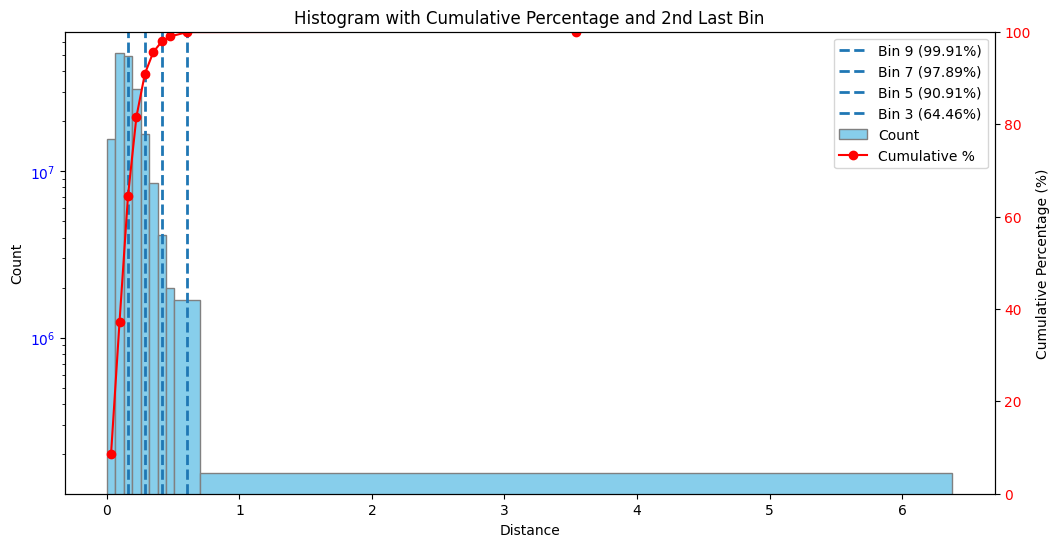

In [174]:
import matplotlib.pyplot as plt

# Bin centers and widths
bin_centers = (results_df['bin_start'] + results_df['bin_end']) / 2
bin_widths = results_df['bin_end'] - results_df['bin_start']

fig, ax1 = plt.subplots(figsize=(12,6))

# Bar plot: counts per bin
ax1.bar(bin_centers, results_df['count'], width=bin_widths, color='skyblue', edgecolor='gray', label='Count')
ax1.set_xlabel('Distance')
ax1.set_ylabel('Count')
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor='blue')

# Line plot: cumulative percentage
ax2 = ax1.twinx()
ax2.plot(bin_centers, results_df['cummulative_percentage'], color='red', marker='o', label='Cumulative %')
ax2.set_ylabel('Cumulative Percentage (%)')
ax2.set_ylim(0, 100)
ax2.tick_params(axis='y', labelcolor='red')

# Add vertical line at 2nd last entry
for i in [len(results_df)-2-i*2 for i in range(0, 4)]:
    bin = results_df.iloc[i]
    vline_pos = (bin['bin_start'] + bin['bin_end']) / 2
    ax1.axvline(x=vline_pos, linestyle='--', linewidth=2, label=f'Bin {i+1} ({bin['cummulative_percentage']:.2f}%)')

# Add legends
fig.legend(loc="upper right", bbox_to_anchor=(0.9,0.88))
plt.title('Histogram with Cumulative Percentage and 2nd Last Bin')
plt.show()